In [1]:
# ==============================================================
# MODEL 6 — CRISIS SCORE ENGINE
# STEP 1 — LOAD DATASET
# ==============================================================

import pandas as pd
import numpy as np

print("=" * 70)
print("MODEL 6 — CRISIS SCORE ENGINE")
print("=" * 70)


# --------------------------------------------------------------
# Load dataset
# --------------------------------------------------------------

df = pd.read_csv(
    "../data/raw/final_dataset.csv"
)


# --------------------------------------------------------------
# Convert Date
# --------------------------------------------------------------

df["Date"] = pd.to_datetime(
    df["Date"],
    errors="coerce"
)


print("\nDataset shape:")
print(df.shape)


print("\nDate range:")
print(
    df["Date"].min(),
    "to",
    df["Date"].max()
)


# --------------------------------------------------------------
# Commodities
# --------------------------------------------------------------

commodities = sorted(
    df["Commodity"].dropna().unique()
)

print("\nCommodities:")
print(commodities)


# --------------------------------------------------------------
# Required columns
# --------------------------------------------------------------

required_columns = [
    "Date",
    "Commodity",
    "Modal_Price",
    "Arrival",
    "Price_Change",
    "Max_Temp",
    "Min_Temp",
    "Rainfall_mm",
    "WindSpeed"
]


print("\nRequired columns check:")

for column in required_columns:

    print(
        f"{column:15} -> {column in df.columns}"
    )


# --------------------------------------------------------------
# Missing values
# --------------------------------------------------------------

print("\nMissing values in required columns:")

print(
    df[required_columns]
    .isnull()
    .sum()
)


# --------------------------------------------------------------
# Remove incomplete rows
# --------------------------------------------------------------

df = df.dropna(
    subset=required_columns
).copy()


# --------------------------------------------------------------
# Sort data
# --------------------------------------------------------------

df = df.sort_values(
    ["Commodity", "Date"]
).reset_index(drop=True)


print("\nRows after cleaning:")
print(len(df))


print("\n" + "=" * 70)
print("MODEL 6 — STEP 1 COMPLETED")
print("=" * 70)

MODEL 6 — CRISIS SCORE ENGINE

Dataset shape:
(54340, 28)

Date range:
2023-01-01 00:00:00 to 2025-12-31 00:00:00

Commodities:
['Onion', 'Potato', 'Rice', 'Tomato', 'Wheat']

Required columns check:
Date            -> True
Commodity       -> True
Modal_Price     -> True
Arrival         -> True
Price_Change    -> True
Max_Temp        -> True
Min_Temp        -> True
Rainfall_mm     -> True
WindSpeed       -> True

Missing values in required columns:
Date            0
Commodity       0
Modal_Price     0
Arrival         0
Price_Change    0
Max_Temp        0
Min_Temp        0
Rainfall_mm     0
WindSpeed       0
dtype: int64

Rows after cleaning:
54340

MODEL 6 — STEP 1 COMPLETED


In [2]:
# ==============================================================
# STEP 2 — CREATE CRISIS SIGNALS
# ==============================================================

print("\n" + "=" * 70)
print("STEP 2 — CREATING CRISIS SIGNALS")
print("=" * 70)


# ==============================================================
# 1. PRICE STRESS
# ==============================================================

# Calculate percentage price movement
df["Price_Change_Percent"] = (
    df.groupby("Commodity")["Modal_Price"]
    .pct_change() * 100
)

# Absolute price movement
df["Abs_Price_Change"] = (
    df["Price_Change_Percent"].abs()
)


# Price stress levels
df["Price_Stress"] = np.select(
    [
        df["Abs_Price_Change"] >= 30,
        df["Abs_Price_Change"] >= 20,
        df["Abs_Price_Change"] >= 10
    ],
    [
        3,
        2,
        1
    ],
    default=0
)


# ==============================================================
# 2. SUPPLY / ARRIVAL STRESS
# ==============================================================

# 30-day average arrival
df["Arrival_Rolling_Mean"] = (
    df.groupby("Commodity")["Arrival"]
    .transform(
        lambda x: x.rolling(
            30,
            min_periods=5
        ).mean()
    )
)


# Percentage difference from normal arrival
df["Arrival_Deviation_Percent"] = (
    (
        df["Arrival"]
        - df["Arrival_Rolling_Mean"]
    )
    / df["Arrival_Rolling_Mean"]
) * 100


# We mainly care about unusually LOW supply
df["Supply_Stress"] = np.select(
    [
        df["Arrival_Deviation_Percent"] <= -50,
        df["Arrival_Deviation_Percent"] <= -30,
        df["Arrival_Deviation_Percent"] <= -15
    ],
    [
        3,
        2,
        1
    ],
    default=0
)


# ==============================================================
# 3. WEATHER STRESS
# ==============================================================

df["Weather_Stress"] = 0


# Extreme heat
df.loc[
    df["Max_Temp"] >= 40,
    "Weather_Stress"
] += 2


df.loc[
    (df["Max_Temp"] >= 35)
    & (df["Max_Temp"] < 40),
    "Weather_Stress"
] += 1


# Heavy rainfall
df.loc[
    df["Rainfall_mm"] >= 100,
    "Weather_Stress"
] += 2


df.loc[
    (df["Rainfall_mm"] >= 50)
    & (df["Rainfall_mm"] < 100),
    "Weather_Stress"
] += 1


# Strong wind
df.loc[
    df["WindSpeed"] >= 30,
    "Weather_Stress"
] += 1


# Cap weather stress at 3
df["Weather_Stress"] = (
    df["Weather_Stress"]
    .clip(upper=3)
)


# ==============================================================
# 4. ANOMALY STRESS
# ==============================================================

# Default = normal
df["Anomaly_Stress"] = 0


# --------------------------------------------------------------
# Recreate anomaly signal from Model 5
# --------------------------------------------------------------

# Calculate rolling price statistics
df["Price_Rolling_Mean"] = (
    df.groupby("Commodity")["Modal_Price"]
    .transform(
        lambda x: x.rolling(
            30,
            min_periods=5
        ).mean()
    )
)

df["Price_Rolling_Std"] = (
    df.groupby("Commodity")["Modal_Price"]
    .transform(
        lambda x: x.rolling(
            30,
            min_periods=5
        ).std()
    )
)


# Price deviation
df["Price_Deviation"] = (
    df["Modal_Price"]
    - df["Price_Rolling_Mean"]
)


# Standardized price deviation
df["Price_ZScore"] = (
    df["Price_Deviation"]
    / df["Price_Rolling_Std"].replace(
        0,
        np.nan
    )
)


# Arrival rolling statistics
df["Arrival_Rolling_Std"] = (
    df.groupby("Commodity")["Arrival"]
    .transform(
        lambda x: x.rolling(
            30,
            min_periods=5
        ).std()
    )
)


df["Arrival_Deviation"] = (
    df["Arrival"]
    - df["Arrival_Rolling_Mean"]
)


# Standardized arrival deviation
df["Arrival_ZScore"] = (
    df["Arrival_Deviation"]
    / df["Arrival_Rolling_Std"].replace(
        0,
        np.nan
    )
)


# --------------------------------------------------------------
# Anomaly condition
# --------------------------------------------------------------

anomaly_condition = (
    (df["Price_ZScore"].abs() >= 2)
    |
    (df["Arrival_ZScore"].abs() >= 2)
)


df.loc[
    anomaly_condition,
    "Anomaly_Stress"
] = 3


# ==============================================================
# DISPLAY SIGNAL DISTRIBUTIONS
# ==============================================================

print("\nPrice Stress distribution:")
print(
    df["Price_Stress"]
    .value_counts()
    .sort_index()
)


print("\nSupply Stress distribution:")
print(
    df["Supply_Stress"]
    .value_counts()
    .sort_index()
)


print("\nWeather Stress distribution:")
print(
    df["Weather_Stress"]
    .value_counts()
    .sort_index()
)


print("\nAnomaly Stress distribution:")
print(
    df["Anomaly_Stress"]
    .value_counts()
    .sort_index()
)


# ==============================================================
# CHECK
# ==============================================================

signal_columns = [
    "Price_Stress",
    "Supply_Stress",
    "Weather_Stress",
    "Anomaly_Stress"
]


print("\nMissing values in crisis signals:")

print(
    df[signal_columns]
    .isnull()
    .sum()
)


print("\n" + "=" * 70)
print("MODEL 6 — STEP 2 COMPLETED")
print("=" * 70)


STEP 2 — CREATING CRISIS SIGNALS

Price Stress distribution:
Price_Stress
0    52811
1      987
2      321
3      221
Name: count, dtype: int64

Supply Stress distribution:
Supply_Stress
0    36635
1     5407
2     3845
3     8453
Name: count, dtype: int64

Weather Stress distribution:
Weather_Stress
0    42184
1     9696
2     2380
3       80
Name: count, dtype: int64

Anomaly Stress distribution:
Anomaly_Stress
0    45253
3     9087
Name: count, dtype: int64

Missing values in crisis signals:
Price_Stress      0
Supply_Stress     0
Weather_Stress    0
Anomaly_Stress    0
dtype: int64

MODEL 6 — STEP 2 COMPLETED


In [3]:
# ==============================================================
# STEP 3 — CALCULATE FINAL CRISIS SCORE
# ==============================================================

print("\n" + "=" * 70)
print("STEP 3 — CALCULATING CRISIS SCORE")
print("=" * 70)


# --------------------------------------------------------------
# Calculate weighted crisis score
# --------------------------------------------------------------

# Maximum raw score:
# Price   = 3
# Supply  = 3
# Weather = 3
# Anomaly = 3
#
# Total = 12
#
# Convert to 0–100 scale.

df["Crisis_Score"] = (
    (
        df["Price_Stress"] * 0.35
        +
        df["Supply_Stress"] * 0.30
        +
        df["Weather_Stress"] * 0.20
        +
        df["Anomaly_Stress"] * 0.15
    )
    / 3
) * 100


# --------------------------------------------------------------
# Make sure score stays between 0 and 100
# --------------------------------------------------------------

df["Crisis_Score"] = (
    df["Crisis_Score"]
    .clip(0, 100)
)


# --------------------------------------------------------------
# Crisis level
# --------------------------------------------------------------

df["Crisis_Level"] = np.select(
    [
        df["Crisis_Score"] >= 80,
        df["Crisis_Score"] >= 60,
        df["Crisis_Score"] >= 30
    ],
    [
        "Critical",
        "High",
        "Moderate"
    ],
    default="Low"
)


# ==============================================================
# DISPLAY CRISIS LEVEL DISTRIBUTION
# ==============================================================

print("\nCrisis Level Distribution:")

print(
    df["Crisis_Level"]
    .value_counts()
)


# ==============================================================
# DISPLAY SCORE STATISTICS
# ==============================================================

print("\nCrisis Score Statistics:")

print(
    df["Crisis_Score"]
    .describe()
)


# ==============================================================
# DISPLAY HIGHEST CRISIS EVENTS
# ==============================================================

print("\nTop 20 Highest Crisis Events:")

top_crisis = (
    df[
        [
            "Date",
            "Commodity",
            "District",
            "Modal_Price",
            "Arrival",
            "Price_Stress",
            "Supply_Stress",
            "Weather_Stress",
            "Anomaly_Stress",
            "Crisis_Score",
            "Crisis_Level"
        ]
    ]
    .sort_values(
        "Crisis_Score",
        ascending=False
    )
    .head(20)
)


print(
    top_crisis.to_string(
        index=False
    )
)


print("\n" + "=" * 70)
print("MODEL 6 — STEP 3 COMPLETED")
print("=" * 70)


STEP 3 — CALCULATING CRISIS SCORE

Crisis Level Distribution:
Crisis_Level
Low         44144
Moderate     9972
High          215
Critical        9
Name: count, dtype: int64

Crisis Score Statistics:
count    54340.000000
mean        11.880352
std         14.776730
min          0.000000
25%          0.000000
50%          6.666667
75%         20.000000
max         93.333333
Name: Crisis_Score, dtype: float64

Top 20 Highest Crisis Events:
      Date Commodity   District  Modal_Price  Arrival  Price_Stress  Supply_Stress  Weather_Stress  Anomaly_Stress  Crisis_Score Crisis_Level
2025-05-01     Wheat Ahmednagar      2535.84    30.00             3              3               2               3     93.333333     Critical
2024-04-21      Rice Ahmednagar      1200.00     2.00             3              3               1               3     86.666667     Critical
2023-04-14      Rice Ahmednagar      8135.32   280.00             3              3               1               3     86.666667    


STEP 4 — CRISIS VISUALIZATION AND SAVE


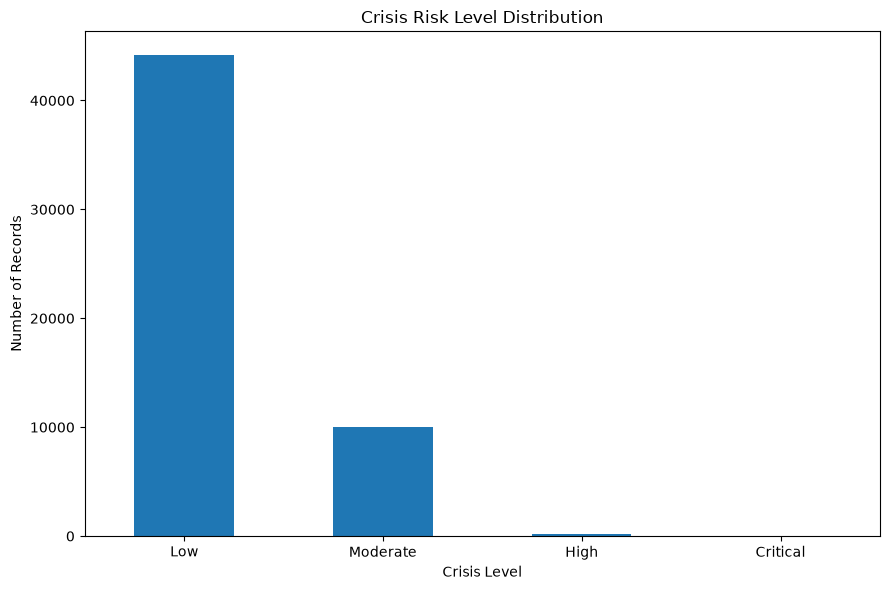

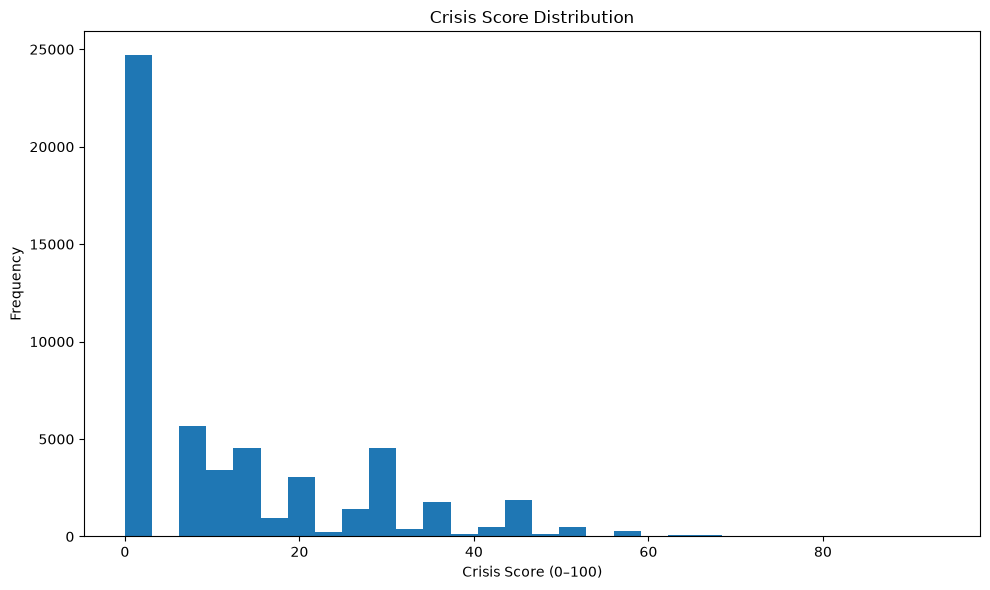

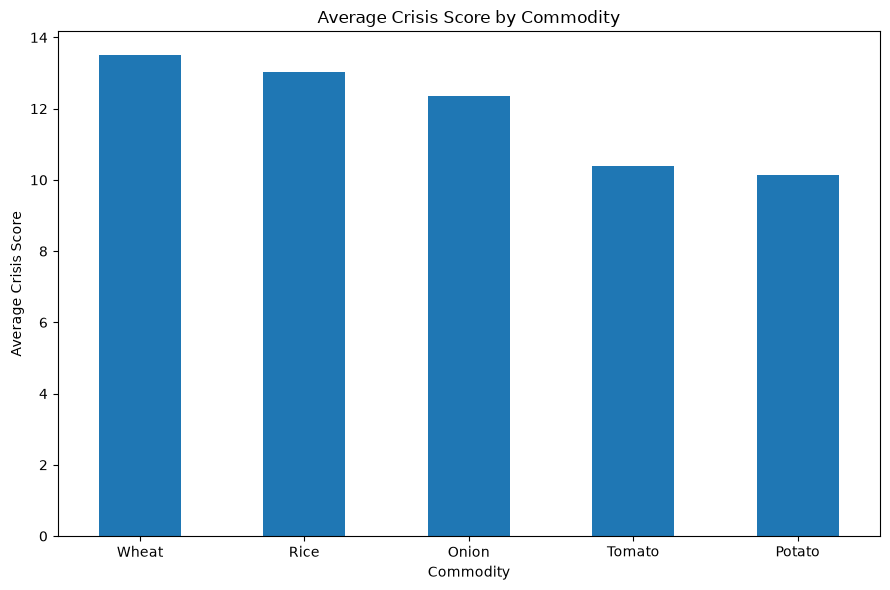


TOP 20 CRISIS EVENTS
      Date Commodity   District  Modal_Price  Arrival  Price_Stress  Supply_Stress  Weather_Stress  Anomaly_Stress  Crisis_Score Crisis_Level
2025-05-01     Wheat Ahmednagar      2535.84    30.00             3              3               2               3     93.333333     Critical
2024-04-21      Rice Ahmednagar      1200.00     2.00             3              3               1               3     86.666667     Critical
2023-04-14      Rice Ahmednagar      8135.32   280.00             3              3               1               3     86.666667     Critical
2024-05-19      Rice Ahmednagar      1200.00     2.00             3              3               1               3     86.666667     Critical
2023-04-14     Wheat Ahmednagar      3568.66   932.17             3              3               1               3     86.666667     Critical
2025-03-30      Rice Ahmednagar      2600.00     2.00             3              3               1               3     86.6666

In [4]:
# ==============================================================
# STEP 4 — CRISIS VISUALIZATION AND SAVE RESULTS
# ==============================================================

import os
import matplotlib.pyplot as plt

print("\n" + "=" * 70)
print("STEP 4 — CRISIS VISUALIZATION AND SAVE")
print("=" * 70)


# ==============================================================
# CREATE OUTPUT DIRECTORY
# ==============================================================

os.makedirs("outputs", exist_ok=True)


# ==============================================================
# 1. CRISIS LEVEL DISTRIBUTION
# ==============================================================

level_order = [
    "Low",
    "Moderate",
    "High",
    "Critical"
]

level_counts = (
    df["Crisis_Level"]
    .value_counts()
    .reindex(level_order)
    .fillna(0)
)


plt.figure(figsize=(9, 6))

level_counts.plot(
    kind="bar"
)

plt.title(
    "Crisis Risk Level Distribution"
)

plt.xlabel(
    "Crisis Level"
)

plt.ylabel(
    "Number of Records"
)

plt.xticks(
    rotation=0
)

plt.tight_layout()

plt.show()


# ==============================================================
# 2. CRISIS SCORE DISTRIBUTION
# ==============================================================

plt.figure(figsize=(10, 6))

plt.hist(
    df["Crisis_Score"],
    bins=30
)

plt.title(
    "Crisis Score Distribution"
)

plt.xlabel(
    "Crisis Score (0–100)"
)

plt.ylabel(
    "Frequency"
)

plt.tight_layout()

plt.show()


# ==============================================================
# 3. CRISIS SCORE BY COMMODITY
# ==============================================================

commodity_crisis = (
    df.groupby("Commodity")["Crisis_Score"]
    .mean()
    .sort_values(
        ascending=False
    )
)


plt.figure(figsize=(9, 6))

commodity_crisis.plot(
    kind="bar"
)

plt.title(
    "Average Crisis Score by Commodity"
)

plt.xlabel(
    "Commodity"
)

plt.ylabel(
    "Average Crisis Score"
)

plt.xticks(
    rotation=0
)

plt.tight_layout()

plt.show()


# ==============================================================
# 4. TOP 20 CRISIS EVENTS
# ==============================================================

top_crisis = (
    df[
        [
            "Date",
            "Commodity",
            "District",
            "Modal_Price",
            "Arrival",
            "Price_Stress",
            "Supply_Stress",
            "Weather_Stress",
            "Anomaly_Stress",
            "Crisis_Score",
            "Crisis_Level"
        ]
    ]
    .sort_values(
        "Crisis_Score",
        ascending=False
    )
    .head(20)
)


print("\n" + "=" * 70)
print("TOP 20 CRISIS EVENTS")
print("=" * 70)

print(
    top_crisis.to_string(
        index=False
    )
)


# ==============================================================
# 5. SAVE COMPLETE CRISIS DATASET
# ==============================================================

output_file = (
    "outputs/crisis_score_results.csv"
)

df.to_csv(
    output_file,
    index=False
)


# ==============================================================
# 6. SAVE ONLY HIGH / CRITICAL EVENTS
# ==============================================================

early_warning_file = (
    "outputs/crisis_early_warning_events.csv"
)

early_warning = df[
    df["Crisis_Level"].isin(
        ["High", "Critical"]
    )
].copy()


early_warning = early_warning.sort_values(
    "Crisis_Score",
    ascending=False
)


early_warning.to_csv(
    early_warning_file,
    index=False
)


# ==============================================================
# FINAL OUTPUT
# ==============================================================

print("\n" + "=" * 70)
print("MODEL 6 — COMPLETED")
print("=" * 70)

print(
    "\n✓ Complete crisis dataset:"
)

print(
    output_file
)

print(
    "\n✓ High/Critical early-warning events:"
)

print(
    early_warning_file
)

print(
    "\nTotal records:",
    len(df)
)

print(
    "High/Critical events:",
    len(early_warning)
)

print(
    "\nCrisis Score Engine successfully completed."
)